# Bias and Variance
### <font color=BLUE>Bias</font> tells us how accurate the model is, on average across different possible training sets while <font color=BLUE>variance</font> tells us how sensitive the learning algorithm is to small changes in the training set.

<img src='bias-variance1.png' width=1000 height=800>
<center>Figure retrieved from the Encyclopedia of Machine Learning</center>

- A model with low variance and low bias is the ideal model
- A model with low bias and high variance is a model with overfitting
- A model with high bias and low variance is usually an underfitting model
- A model with high bias and high variance is the worst case scenario, as it is a model that produces the greatest possible prediction error.


## Bias and Variance of Models

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest,f_classif,RFE
from sklearn.model_selection import train_test_split,cross_val_score

#classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

#regressors
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn import metrics
from sklearn.model_selection import learning_curve,LearningCurveDisplay
from mlxtend.evaluate import bias_variance_decomp

In [2]:
!pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 10.9 MB/s  0:00:00


## Example 1: Boston Dataset (Regression)

In [28]:
boston_df=pd.read_csv('dataset/boston.csv')
boston_df.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [33]:
X.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'black', 'lstat'],
      dtype='str')

In [30]:
X=boston_df.iloc[:,1:-1]
y=boston_df['medv']
svr = SVR(kernel="linear", C=1)
selector = RFE(estimator=svr, n_features_to_select=10, step=1)
selector.fit(X, y)
selector1=SelectKBest(k=10).fit(X, y)
print(selector.get_support())
print(selector1.get_support())

features=X.columns[selector.get_support()]
X_train, X_test, y_train, y_test = train_test_split(X[features], y, test_size=0.2, random_state=42)
features

[ True  True  True  True  True  True  True  True False False  True False
  True]
[ True False  True False  True  True  True False  True  True  True  True
  True]


Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'ptratio',
       'lstat'],
      dtype='str')

In [5]:
X.columns.values

<StringArray>
[   'crim',      'zn',   'indus',    'chas',     'nox',      'rm',     'age',
     'dis',     'rad',     'tax', 'ptratio',   'black',   'lstat']
Length: 13, dtype: str

In [6]:
np.array(X_train.head())

array([[1.50234e+01, 0.00000e+00, 1.81000e+01, 0.00000e+00, 6.14000e-01,
        5.30400e+00, 9.73000e+01, 2.10070e+00, 2.02000e+01, 2.49100e+01],
       [6.27390e-01, 0.00000e+00, 8.14000e+00, 0.00000e+00, 5.38000e-01,
        5.83400e+00, 5.65000e+01, 4.49860e+00, 2.10000e+01, 8.47000e+00],
       [3.46600e-02, 3.50000e+01, 6.06000e+00, 0.00000e+00, 4.37900e-01,
        6.03100e+00, 2.33000e+01, 6.64070e+00, 1.69000e+01, 7.83000e+00],
       [7.05042e+00, 0.00000e+00, 1.81000e+01, 0.00000e+00, 6.14000e-01,
        6.10300e+00, 8.51000e+01, 2.02180e+00, 2.02000e+01, 2.32900e+01],
       [7.25800e-01, 0.00000e+00, 8.14000e+00, 0.00000e+00, 5.38000e-01,
        5.72700e+00, 6.95000e+01, 3.79650e+00, 2.10000e+01, 1.12800e+01]])

In [34]:
# Initialize the models
r_models = [
    ('Linear Regression', LinearRegression()),
    ('SVM', SVR()),
    ('KNN', KNeighborsRegressor(n_neighbors=2)),
    ('CART', DecisionTreeRegressor())
]

results = []

for name, model in r_models:
    model.fit(X_train, y_train)
    mse, bias, variance = bias_variance_decomp(model, np.array(X_train), np.array(y_train), np.array(X_test), np.array(y_test), loss='mse', num_rounds=200, random_seed=4)
    y_pred = model.predict(X_test)
    r2 = metrics.r2_score(y_test, y_pred),
    mae = metrics.mean_absolute_error(y_test, y_pred)
    rmse = metrics.mean_squared_error(y_test, y_pred)
    results.append((name, r2,mae,mse,rmse, bias,variance))

C:\Users\LJFelix\Desktop\CC105\Lecture\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
C:\Users\LJFelix\Desktop\CC105\Lecture\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(
C:\Users\LJFelix\Desktop\CC105\Lecture\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(
C:\Users\LJFelix\Desktop\CC105\Lecture\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


In [35]:
results_df = pd.DataFrame(results, columns=['Model', 'R-Squared','MAE','MSE','RMSE','Bias','Variance'])
results_df

,Model,R-Squared,MAE,MSE,RMSE,Bias,Variance
0,Linear Regression,"(0.6623187873939346,)",3.259226,25.481472,24.763441,24.680713,0.800759
1,SVM,"(0.4721313028003463,)",3.786468,40.997303,38.710609,40.481088,0.516215
2,KNN,"(0.49399474822346945,)",3.874020,36.314520,37.107279,26.204690,10.109830
3,CART,"(0.6252509618138549,)",3.388235,21.817004,27.481765,9.515311,12.301693


In [11]:
X.shape

(506, 13)

In [12]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error
y_true = np.array([3, -0.5, 2, 7])
y_pred = np.array([2.5, 0.0, 2, 8])
mean_absolute_error(y_true, y_pred)

0.5

In [13]:
np.abs(y_true-y_pred)

array([0.5, 0.5, 0. , 1. ])

In [14]:
np.mean(np.abs(y_pred-y_true))

np.float64(0.5)

In [15]:
mean_squared_error(y_true,y_pred)

0.375

In [16]:
np.mean((y_true-y_pred)**2) #MSE

np.float64(0.375)

In [17]:
root_mean_squared_error(y_true,y_pred)

0.6123724356957945

In [18]:
np.sqrt(np.mean((y_true-y_pred)**2)) #RMSE

np.float64(0.6123724356957945)

In [19]:
np.abs(y_pred-y_true)

array([0.5, 0.5, 0. , 1. ])

In [20]:
np.mean(np.abs(y_pred-y_true)) #MAE

np.float64(0.5)

In [21]:
y_pred[:10]

array([2.5, 0. , 2. , 8. ])

In [22]:
y_test[:10].values

array([23.6, 32.4, 13.6, 22.8, 16.1, 20. , 17.8, 14. , 19.6, 16.8])

**Cross-validation** is a statistical method of evaluating generalization performance that is more stable and thorough than using a split into a training and a test set. In crossvalidation, the data is instead split repeatedly and multiple models are trained. The most commonly used version of cross-validation is k-fold cross-validation, where k is a user-specified number, usually 5 or 10.

When performing five-fold cross-validation,
the data is first partitioned into five parts of (approximately) equal size, called folds.
Next, a sequence of models is trained. The first model is trained using the first fold as
the test set, and the remaining folds (2–5) are used as the training set. The model is
built using the data in folds 2–5, and then the accuracy is evaluated on fold 1. Then
another model is built, this time using fold 2 as the test set and the data in folds 1, 3,
4, and 5 as the training set. This process is repeated using folds 3, 4, and 5 as test sets.
For each of these five splits of the data into training and test sets, we compute the
accuracy. In the end, we have collected five accuracy values.

In [36]:
for name, model in r_models:
    #this is 10-fold cross validation, try changing cv to 5 and run again the code
    scores = cross_val_score(model, X_train, y_train, cv=10, scoring='r2')
    print(name,', ave score=',np.mean(scores))
    print(scores)
    print('-'*50)

Linear Regression , ave score= 0.682913142550692
[0.73388388 0.76928563 0.74833837 0.29977209 0.76559996 0.71039352
 0.84166395 0.67781912 0.77665855 0.50571635]
--------------------------------------------------
SVM , ave score= 0.31333718650548176
[0.3168514  0.33496367 0.22561383 0.42279456 0.24537725 0.34720832
 0.2819278  0.36071262 0.3443922  0.25353022]
--------------------------------------------------
KNN , ave score= 0.543467744937284
[0.40172353 0.60827569 0.65511673 0.71280697 0.64408111 0.61882879
 0.58183168 0.40959351 0.52936655 0.27305289]
--------------------------------------------------
CART , ave score= 0.6471291551491254
[0.69403669 0.78986892 0.80657661 0.16368652 0.33531904 0.85724616
 0.79959236 0.55850474 0.84335389 0.62310663]
--------------------------------------------------


Interpreting the results of a learning curve can provide valuable insights into the performance and behavior of a machine learning model. Here's how to interpret the key aspects of a learning curve:

Training Set Size (x-axis): The x-axis represents the size of the training set, which starts with a small portion of the data and gradually increases. This shows how the model's performance changes as more training data is used.

<b> Accuracy (y-axis) </b>: The y-axis typically represents the accuracy of the model, although it could be any performance metric. Accuracy measures the percentage of correctly classified instances. Other common metrics include precision, recall, F1-score, and mean squared error (for regression tasks).

<b>Training Accuracy (blue line) </b>: The blue line represents the accuracy on the training set as the training set size increases. This line shows how well the model fits the training data. Initially, with a small training set, the model can fit the data well, resulting in high training accuracy. As the training set size increases, the training accuracy may decrease slightly as the model generalizes better.

<b>Cross-Validation Accuracy (red line) </b>: The red line represents the accuracy on a separate cross-validation (testing) set. This line shows how well the model generalizes to unseen data as the training set size increases. The cross-validation accuracy is a better indicator of the model's ability to make predictions on new, unseen data.

<b>Uncertainty (shaded regions) </b>: The shaded regions around the lines represent the standard deviation of the accuracy scores. Larger shaded regions indicate higher uncertainty in the accuracy estimate. Smaller shaded regions imply more stable performance.

Interpretation:

If both the training and cross-validation accuracies are low, it suggests underfitting. The model may not be complex enough to capture the underlying patterns in the data. Increasing the model's complexity or using more features may be necessary.

If the training accuracy is high, but the cross-validation accuracy is significantly lower, it suggests overfitting. The model is memorizing the training data and does not generalize well to new data. Regularization techniques or reducing model complexity can help address overfitting.

If both training and cross-validation accuracies are high and close to each other, it indicates a well-fitted model that generalizes effectively to new data.

If there is a large gap between the training and cross-validation accuracies, it may suggest a high variance problem. You can address this by collecting more data, reducing model complexity, or applying regularization.

In summary, the learning curve helps you understand how your model's performance changes with different training set sizes and provides insights into potential issues like underfitting, overfitting, and data requirements. It can guide you in making decisions about model complexity, data collection, and the need for regularization.

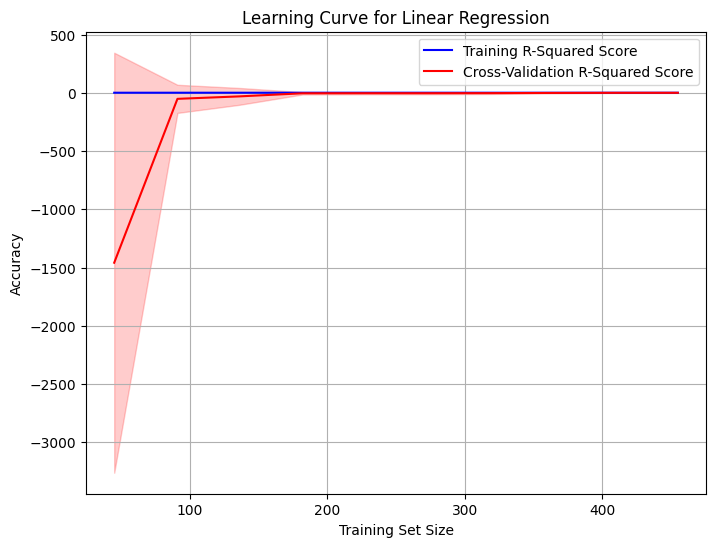

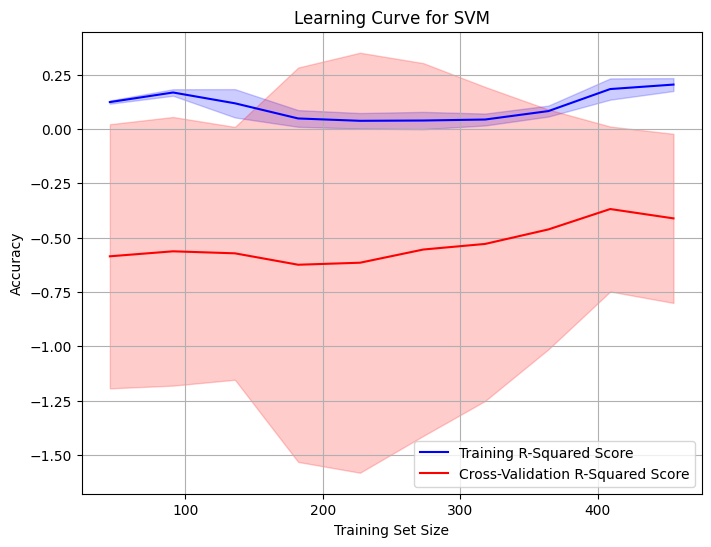

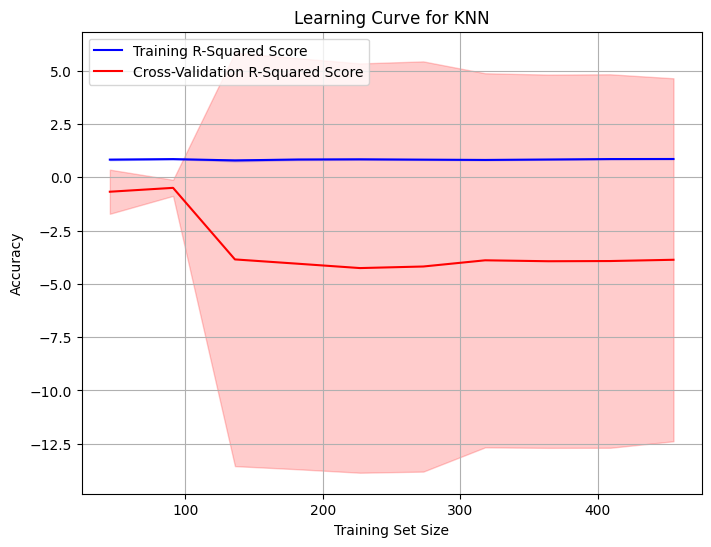

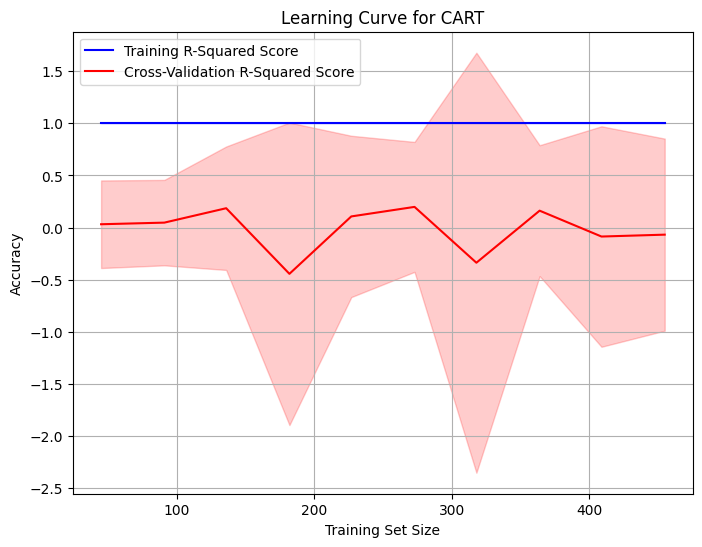

In [37]:
for name, model in r_models:
    # Create learning curves
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, train_sizes=np.linspace(0.1, 1.0, 10), cv=10, scoring='r2')

    # Calculate the mean and standard deviation of the training and testing scores
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Plot the learning curve
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_mean, label='Training R-Squared Score', color='blue')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.2)
    plt.plot(train_sizes, test_mean, label='Cross-Validation R-Squared Score', color='red')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color='red', alpha=0.2)
    plt.title('Learning Curve for '+ name)
    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy')
    plt.legend(loc='best')
    plt.grid()
    plt.show()

In [25]:
#create reusable function for plotting learning curvve
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5),mscore='neg_root_mean_squared_error'):
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring=mscore)
    train_scores_mean = -np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.legend(loc="best")
    return plt

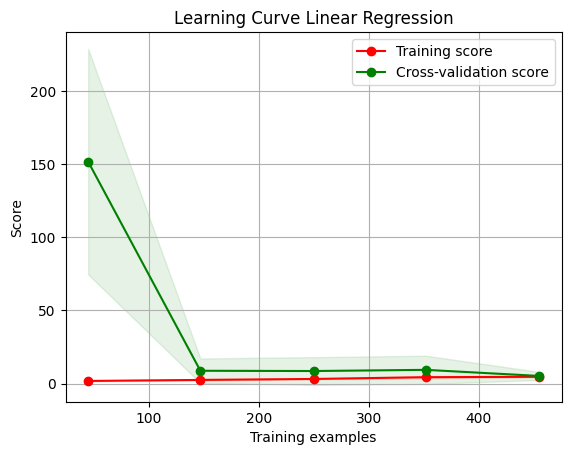

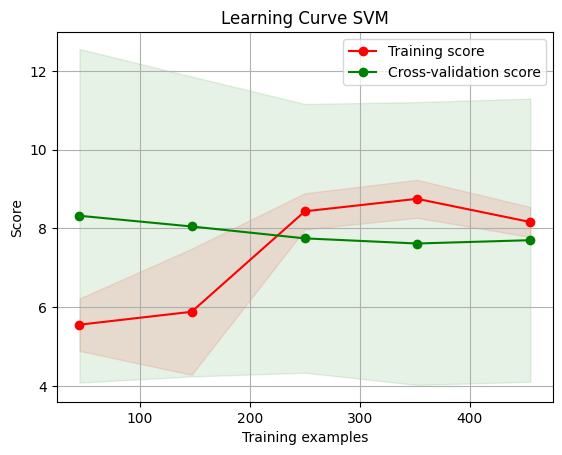

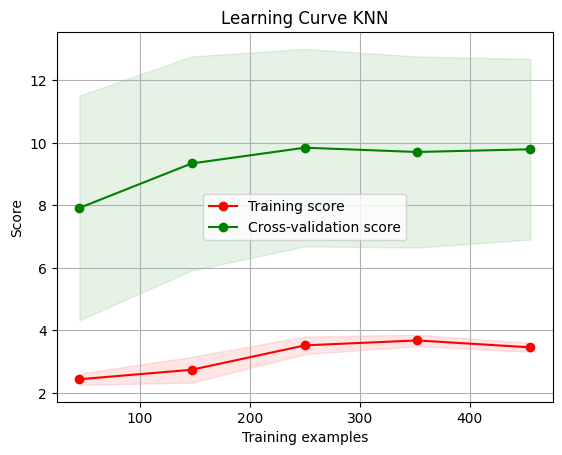

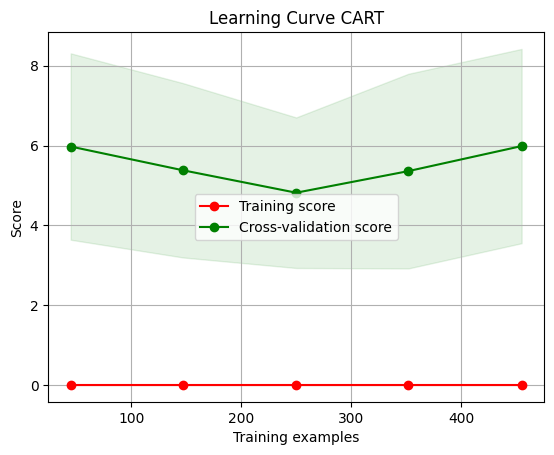

In [26]:
# Plot the learning curve
for name, model in r_models:
    plot_learning_curve(model,'Learning Curve '+name, X, y, cv=10)
    plt.show()

## Example 2: Breast Cancer Dataset (Classification)

## PERFORMANCE METRICS FOR CLASSIFICATION
- <b>Accuracy</b> =  (TP + TN) / (TP + TN + FP + FN)
Use when you want a general measure of how often your model's predictions are correct. It's suitable for balanced datasets.

- <b>Precision (Positive Predictive Value)</b> = TP / (TP + FP)
Use when you want to know how many of the predicted positive cases are actually true positives. It's important when false positives are costly.

- <b>Recall (Sensitivity or True Positive Rate)</b> = TP / (TP + FN)
Use when you want to know how many of the true positive cases were correctly predicted by the model. It's important when false negatives are costly.

- <b>Specificity (True Negative Rate)</b> = TN / (TN + FP)
Use when you want to know how well your model avoids false positives. It's essential when you want to minimize the rate of false alarms.

- <b>ROC-AUC (Receiver Operating Characteristic - Area Under the Curve):</b>
ROC-AUC is not a single formula, but it quantifies the model's ability to distinguish between positive and negative classes by measuring the area under the ROC curve.
Use when you want to assess the model's overall ability to separate the classes. A higher AUC indicates better discrimination.

- <b>F1 Score (F1-Measure)</b> =  2 * (Precision * Recall) / (Precision + Recall)
Use when you want to balance precision and recall. It's especially valuable when you have imbalanced classes and want to consider both false positives and false negatives.
<hr>

The choice of the metric depends on the specific goals and constraints of your classification problem, as well as the relative costs associated with false positives and false negatives.

In [ ]:
cancer = load_breast_cancer()
X_cancer = pd.DataFrame(data=cancer.data,columns=cancer.feature_names)
y_cancer = pd.Series(data=cancer.target, name='class') # Target
cancer_df=pd.concat([X_cancer,y_cancer],axis=1)
cancer_df.sample(5)

c_selector=SelectKBest(f_classif, k=15)
c_selector.fit_transform(X_cancer, y_cancer)
c_features=X_cancer.columns[c_selector.get_support()]
X_train, X_test, y_train, y_test = train_test_split(X_cancer[c_features], y_cancer, test_size=0.2, random_state=42)


In [ ]:
# Initialize the models
c_models = [
    ('Logistic Regression', LogisticRegression(max_iter=10000)),
    ('Random Forest', RandomForestClassifier()),
    ('SVM', SVC(probability=True)),
    ('KNN', KNeighborsClassifier()),
    ('Gradient Boosting', GradientBoostingClassifier()),
    ('CART', DecisionTreeClassifier())
]

results = []

for name, model in c_models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    loss, bias, variance = bias_variance_decomp(model, np.array(X_train), np.array(y_train), np.array(X_test), np.array(y_test), loss='0-1_loss', num_rounds=200, random_seed=4)
    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)
    accuracy = metrics.accuracy_score(y_test, y_pred)
    precision = metrics.precision_score(y_test, y_pred)
    recall = metrics.recall_score(y_test, y_pred)
    f1 = metrics.f1_score(y_test, y_pred)
    conf_matrix = metrics.confusion_matrix(y_test, y_pred)
    auc = metrics.roc_auc_score(y_test, y_pred)
    results.append((name, accuracy, train_accuracy, test_accuracy, precision, recall, f1, auc,conf_matrix,loss,bias,variance))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.wa

In [ ]:
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy','Train Accuracy', 'Test Accuracy','Precision', 'Recall', 'F1 Score','ROC-AUC','Confusion Matrix','Loss','Bias','Variance'])
results_df

,Model,Accuracy,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,Confusion Matrix,Loss,Bias,Variance
0,Logistic Regression,0.982456,0.945055,0.991228,0.972603,1.000000,0.986111,0.976744,"[[41, 2], [0, 71]]",0.015395,0.008772,0.010833
1,Random Forest,0.956140,0.978022,0.947368,0.958333,0.971831,0.965035,0.951032,"[[40, 3], [2, 69]]",0.043246,0.043860,0.008158
2,SVM,0.947368,0.912088,0.947368,0.922078,1.000000,0.959459,0.930233,"[[37, 6], [0, 71]]",0.057105,0.052632,0.004474
3,KNN,0.947368,0.940659,0.912281,0.933333,0.985915,0.958904,0.934818,"[[38, 5], [1, 70]]",0.057807,0.052632,0.033509
4,Gradient Boosting,0.956140,0.975824,0.929825,0.958333,0.971831,0.965035,0.951032,"[[40, 3], [2, 69]]",0.050746,0.052632,0.017412
5,CART,0.929825,0.964835,0.938596,0.931507,0.957746,0.944444,0.920734,"[[38, 5], [3, 68]]",0.068596,0.043860,0.040175


### The performance metrics for the model for classifying breast cancer as malignant or benign as shown in the table above tells us that the __Logistic Regression Model__ has the best performance, with a 98.24% classification accuracy,98.61% F1 Score, lowest bias score of 0.010833 and loss or misclassification rate of 0.015295.

### The Learning Curve plotted below also confirms that the logistict regression is more stable. The training and cross validatation learning curve converges as input size is increased. It is normal for training accuracy to decrease as the model is fed with more data. This means that the __model generalizes well and is stable__  across different subsets of the data. On the other hand, the validation score improves because the model generalizes better with more data.

## Plot learning Curve

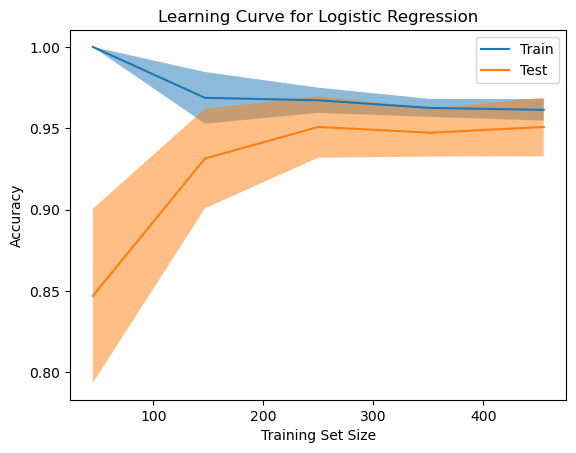

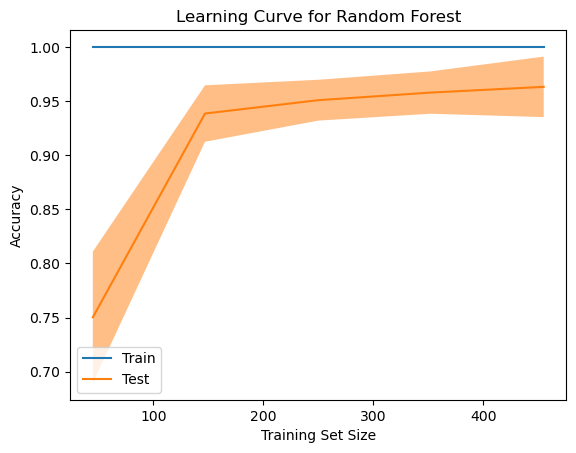

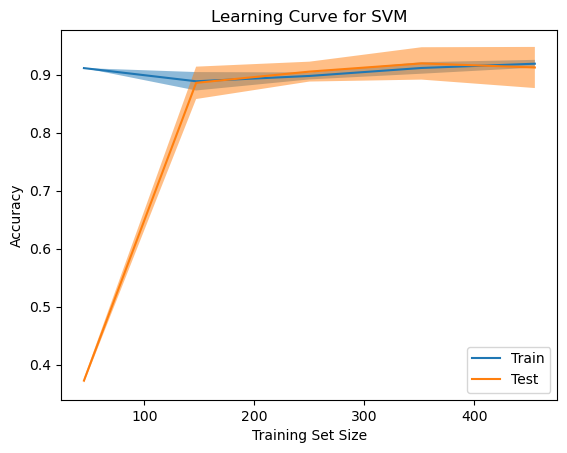

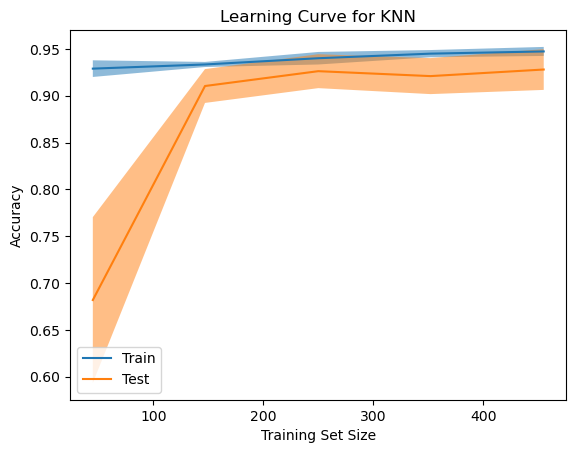

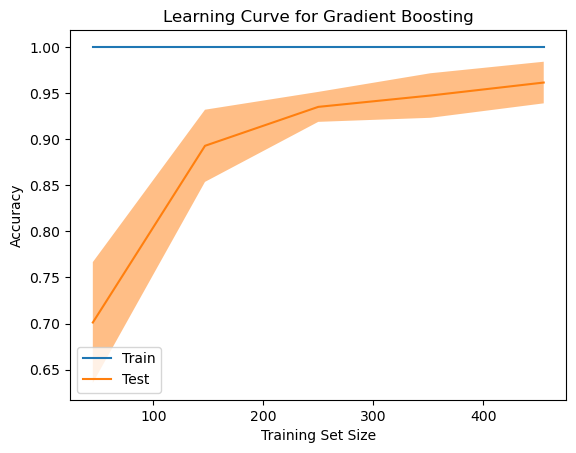

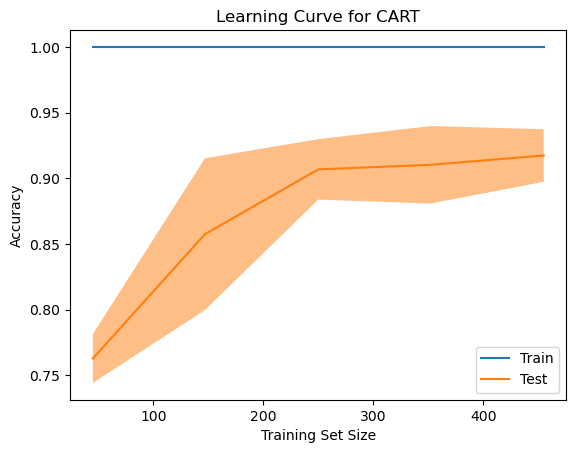

In [ ]:
for name, model in c_models:
    LearningCurveDisplay.from_estimator(model, X_cancer, y_cancer, train_sizes=np.linspace(0.1, 1.0, 5), cv=5)
    plt.title('Learning Curve for '+ name)
    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy')

In [ ]:
#accuracy
980/1000

0.98

In [ ]:
#precision
980/(980+20)

0.98

In [ ]:
#recall
980/(980)

1.0

In [ ]:
#specificity
0/(0+20)

0.0